# Simulated Annealing ABC (SABC)

## Basic tests
---

This notebook contains basic sanity checks for the SABC implementation,
using a simple Gaussian toy model. The goal is to verify convergence,
compare single- and multi-epsilon schemes, and validate posterior recovery.

The observed data are generated from a normal distribution with unknown mean and standard deviation.
Inference is performed on the parameters `(mu, sigma)` using **3 summary stats**: empirical **mean**, **standard deviation** and a **randomly generated** number. The latter is just uninformative noise.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.stats import norm
from scipy.stats import gaussian_kde
from pathlib import Path
from simulated_annealing_abc import (
    sabc,
    update_population,
    DifferentialEvolution,
    StretchMove,
    RandomWalk,
    save_sabc_result,
    load_sabc_result,
)

In [2]:
# Path of *this* script
HERE = Path.cwd()

### Generate data from N(mu,sigma)
---

In [3]:
# -------------------------
# Reproducibility
# -------------------------
np.random.seed(1822)

In [4]:
# -------------------------
# True data-generating process
# -------------------------
true_mu = 10.0
true_sigma = 15.0
num_samples = 1000

y_obs = np.random.normal(true_mu, true_sigma, size=num_samples)

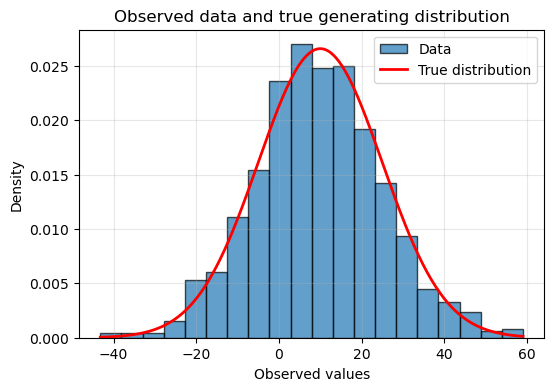

In [5]:
# Plot the observed data and true distribution

x = np.linspace(y_obs.min(), y_obs.max(), 300)

plt.figure(figsize=(6, 4))
plt.hist(y_obs, bins=20, density=True, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, norm.pdf(x, true_mu, true_sigma), "r-", lw=2, label="True distribution")
plt.xlabel("Observed values")
plt.ylabel("Density")
plt.title("Observed data and true generating distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### True posterior
---

In [6]:
# -------------------------
# Prior definition
# -------------------------
mu_min, mu_max = -10.0, 20.0
sigma_min, sigma_max = 0.0, 25.0

In [7]:
# -------------------------
# Generate true posterior samples using MCMC
# -------------------------
def log_prior(theta):
    mu, sigma = theta
    if (mu_min <= mu <= mu_max) and (sigma_min <= sigma <= sigma_max):
        # uniform prior -> constant inside bounds
        return -np.log(mu_max - mu_min) - np.log(sigma_max - sigma_min)
    return -np.inf

def log_likelihood(theta, y):
    mu, sigma = theta
    if sigma <= 0:
        return -np.inf
    n = y.size
    # Normal log-likelihood
    return -n*np.log(sigma) - 0.5*np.sum((y - mu)**2) / (sigma**2)

def log_posterior(theta, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y)

# --- MCMC settings ---
ndim = 2
nwalkers = 20              # number of walkers
burnin = 10000
nsteps = 5000              # production steps per walker
thin = 100

# --- initialize walkers uniformly from the prior ---
p0 = np.empty((nwalkers, ndim))
p0[:, 0] = np.random.uniform(mu_min, mu_max, size=nwalkers)       # mu
p0[:, 1] = np.random.uniform(max(sigma_min, 1e-6), sigma_max, size=nwalkers)  # sigma

# --- run MCMC ---
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(y_obs,))
sampler.run_mcmc(p0, burnin + nsteps, progress=True)

# --- discard burn-in, thin, flatten ---
flat = sampler.get_chain(discard=burnin, thin=thin, flat=True)
mu_truepost = flat[:, 0]
sigma_truepost = flat[:, 1]

100%|██████████| 15000/15000 [00:05<00:00, 2959.15it/s]


In [8]:
mu_truepost.shape, sigma_truepost.shape

((1000,), (1000,))

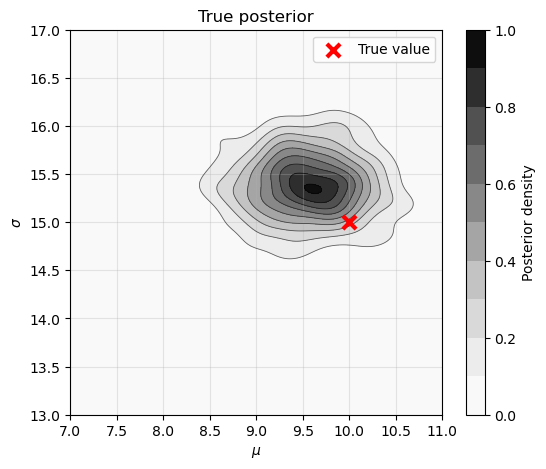

In [9]:
# -------------------------
# Plot true posterior
# -------------------------

# KDE from true posterior samples
values = np.vstack([mu_truepost, sigma_truepost])
kde = gaussian_kde(values)

# Grid (manual zoom region)
mu_lims = (7, 11)
sigma_lims = (13, 17)       
mu_grid = np.linspace(mu_lims[0], mu_lims[1], 250)
sig_grid = np.linspace(sigma_lims[0], sigma_lims[1], 250)
MU, SIG = np.meshgrid(mu_grid, sig_grid)

# Evaluate density
positions = np.vstack([MU.ravel(), SIG.ravel()])
Z = kde(positions).reshape(MU.shape)

plt.figure(figsize=(6, 5))
plt.grid(True, alpha=0.3, zorder=0)

# Shaded contours (grayscale)
n_levels = 10
cf = plt.contourf(
    MU,
    SIG,
    Z,
    levels=n_levels,
    cmap="Greys",
    zorder=1
)

# Contour lines
plt.contour(
    MU,
    SIG,
    Z,
    levels=n_levels,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
    zorder=2
)

# True parameters
plt.scatter(
    true_mu,
    true_sigma,
    c="red",
    s=90,
    linewidths=3.0,
    marker="x",
    zorder=3,
    label="True value"
)

plt.xlim(mu_lims)
plt.ylim(sigma_lims)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.title("True posterior")
plt.colorbar(cf, label="Posterior density")
plt.legend()
plt.show()

### Setup SABC inference
---

In [10]:
# IMPORTANT -> Prior must be defined so that 
# it can generate samples (with prior.rvs) 
# and compute logpdf (with prior.logpdf)

class Prior:
    """Independent Uniform prior for (mu, sigma)."""

    def rvs(self):
        mu = np.random.uniform(mu_min, mu_max)
        sigma = np.random.uniform(sigma_min, sigma_max)
        return np.array([mu, sigma], dtype=float)

    def logpdf(self, theta):
        mu, sigma = theta
        if (mu_min <= mu <= mu_max) and (sigma_min <= sigma <= sigma_max):
            return -np.log(mu_max - mu_min) - np.log(sigma_max - sigma_min)
        return -np.inf

In [12]:
prior = Prior()

In [11]:
# -------------------------
# Summary statistics (empirical mu, median and sigma)
# -------------------------
def sum_stats(data):
    stat1 = np.mean(data)
    stat2 = np.std(data, ddof=0)
    stat3 = np.random.randn()
    return np.array([stat1, stat2, stat3], dtype=float)

In [13]:
ss_obs = sum_stats(y_obs)
print("Observed summary statistics:", ss_obs)
n_stats = ss_obs.size
print("Number of summary statistics:", n_stats)

Observed summary statistics: [ 9.57676543 15.37265592  0.34480592]
Number of summary statistics: 3


In [14]:
# -------------------------
# Model + distance
# -------------------------
def model(theta):
    mu, sigma = theta
    y = np.random.normal(mu, sigma, size=num_samples)
    return sum_stats(y)

def f_dist(theta):
    ss = model(theta)
    rho = np.abs(ss - ss_obs)   # Euclidean in 1D == abs
    return rho

In [15]:
# -------------------------
# SABC parameters
# -------------------------
n_particles = 1000
n_simulation = 1_000_000
v = 1.0

### Run SABC (DE, single_eps, 3 stats)
---

In [16]:
# -------------------------
# Run: Differential Evolution, Single Epsilon
# -------------------------
out_dif = sabc(
    f_dist,
    prior,
    n_particles=n_particles,
    n_simulation=n_simulation,
    v=v,
    show_checkpoint=200,
    algorithm="single_eps",
    proposal=DifferentialEvolution(n_para=2),
)

[INFO] Initialization for 'single_eps'


999 population updates::   0%|          | 0/999 [00:00<?, ?it/s]

[INFO] All particles have been updated 999 times.


In [17]:
# -------------------------
# Use update_population to continue from previous result
# -------------------------
out_dif_2 = update_population(
    out_dif, f_dist, prior,
    n_simulation=n_simulation,
    v=v,
    show_checkpoint=200,
    proposal=DifferentialEvolution(n_para=2)
    )    

1000 population updates::   0%|          | 0/1000 [00:00<?, ?it/s]

[INFO] All particles have been updated 1000 times.


In [18]:
# Population (n_particles × n_params)
pop_dif = np.column_stack(out_dif_2.population)

# Epsilon history
eps_dif = np.column_stack(out_dif_2.state.epsilon_history)

# Mean rho history
rho_dif = np.column_stack(out_dif_2.state.rho_history)

# Mean u history
u_dif = np.column_stack(out_dif_2.state.u_history)

In [19]:
pop_dif.shape, eps_dif.shape, rho_dif.shape, u_dif.shape

((2, 1000), (1, 2000), (3, 2000), (3, 2000))

In [20]:
# -------------------------
# Posterior sample
# -------------------------
mu = pop_dif[0, :]
sigma = pop_dif[1, :]

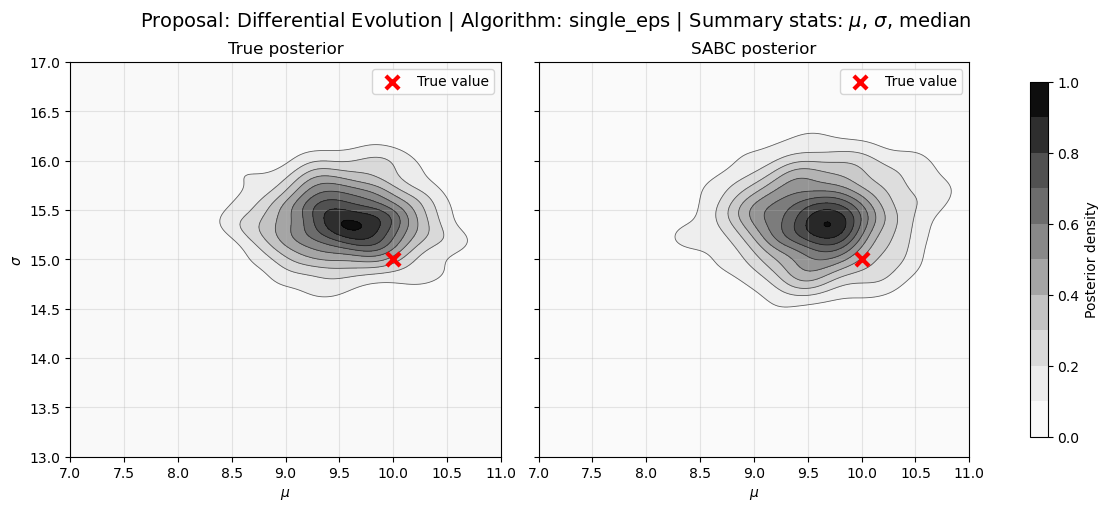

In [21]:

# -------------------------
# Compare true and sabc-inferred posteriors
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# -------------------------
# LEFT: True posterior
# -------------------------
ax = axes[0]
ax.grid(True, alpha=0.3, zorder=0)

cf = ax.contourf(
    MU,
    SIG,
    Z,
    levels=n_levels,
    cmap="Greys",
    zorder=1
)

ax.contour(
    MU,
    SIG,
    Z,
    levels=n_levels,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
    zorder=2
)

ax.scatter(
    true_mu,
    true_sigma,
    c="red",
    s=90,
    linewidths=3.0,
    marker="x",
    zorder=3,
    label="True value"
)

ax.set_xlim(mu_lims)
ax.set_ylim(sigma_lims)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.set_title("True posterior")
ax.legend()

# -------------------------
# RIGHT: SABC posterior
# -------------------------
ax = axes[1]
ax.grid(True, alpha=0.3, zorder=0)

# KDE of SABC posterior (same style!)
values_sabc = np.vstack([mu, sigma])
kde_sabc = gaussian_kde(values_sabc)

positions = np.vstack([MU.ravel(), SIG.ravel()])
Z_sabc = kde_sabc(positions).reshape(MU.shape)

ax.contourf(
    MU,
    SIG,
    Z_sabc,
    levels=n_levels,
    cmap="Greys",
    zorder=1
)

ax.contour(
    MU,
    SIG,
    Z_sabc,
    levels=n_levels,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
    zorder=2
)

ax.scatter(
    true_mu,
    true_sigma,
    c="red",
    s=90,
    linewidths=3.0,
    marker="x",
    zorder=3,
    label="True value"
)

ax.set_xlabel(r"$\mu$")
ax.set_title(r"SABC posterior")
ax.legend()

# -------------------------
# ONE shared colorbar
# -------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.9)
cbar.set_label("Posterior density")

fig.suptitle(
    r"Proposal: Differential Evolution | Algorithm: single_eps | Summary stats: $\mu$, $\sigma$, median",
    fontsize=14
)

plt.show()

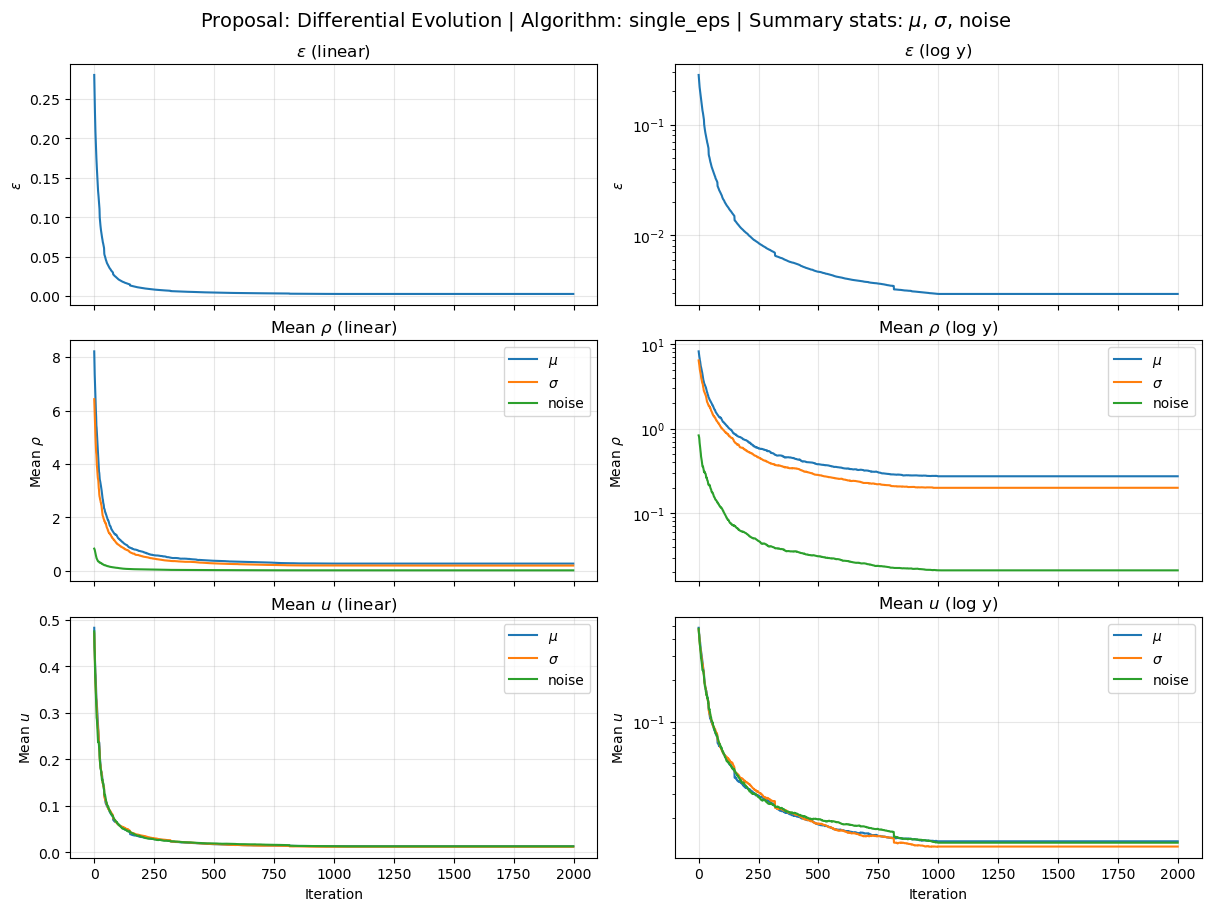

In [22]:

T = eps_dif.shape[1]
it = np.arange(T)

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True
)

# =====================================================
# ε
# =====================================================
# linear
ax = axes[0, 0]
ax.plot(it, eps_dif[0, :])
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"$\epsilon$")
ax.set_title(r"$\epsilon$ (linear)")

# log
ax = axes[0, 1]
ax.plot(it, eps_dif[0, :])
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"$\epsilon$")
ax.set_title(r"$\epsilon$ (log y)")

# =====================================================
# ρ
# =====================================================
# linear
ax = axes[1, 0]
ax.plot(it, rho_dif[0, :], label=r"$\mu$")
ax.plot(it, rho_dif[1, :], label=r"$\sigma$")
ax.plot(it, rho_dif[2, :], label=r"noise")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $\rho$")
ax.set_title(r"Mean $\rho$ (linear)")
ax.legend()

# log
ax = axes[1, 1]
ax.plot(it, rho_dif[0, :], label=r"$\mu$")
ax.plot(it, rho_dif[1, :], label=r"$\sigma$")
ax.plot(it, rho_dif[2, :], label=r"noise")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $\rho$")
ax.set_title(r"Mean $\rho$ (log y)")
ax.legend()

# =====================================================
# u
# =====================================================
# linear
ax = axes[2, 0]
ax.plot(it, u_dif[0, :], label=r"$\mu$")
ax.plot(it, u_dif[1, :], label=r"$\sigma$")
ax.plot(it, u_dif[2, :], label=r"noise")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $u$")
ax.set_xlabel("Iteration")
ax.set_title(r"Mean $u$ (linear)")
ax.legend()

# log
ax = axes[2, 1]
ax.plot(it, u_dif[0, :], label=r"$\mu$")
ax.plot(it, u_dif[1, :], label=r"$\sigma$")
ax.plot(it, u_dif[2, :], label=r"noise")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $u$")
ax.set_xlabel("Iteration")
ax.set_title(r"Mean $u$ (log y)")
ax.legend()

fig.suptitle(
    r"Proposal: Differential Evolution | Algorithm: single_eps | Summary stats: $\mu$, $\sigma$, noise",
    fontsize=14
)

plt.show()

In [40]:
save_sabc_result(out_dif_2, HERE / "test_results" / "out_DE_sing_3statsNoise.pkl")

# -------------------------
# out_dif_2 = load_sabc_result(HERE / "test_results" / "out_DE_sing_3statsNoise.pkl")
# -------------------------

### Run SABC (DE, multi_eps, 3 stats)
---

In [41]:
# -------------------------
# Run: Differential Evolution, Multi Epsilon
# -------------------------
out_dif_mult = sabc(
    f_dist,
    prior,
    n_particles=n_particles,
    n_simulation=n_simulation,
    v=v,
    show_checkpoint=200,
    algorithm="multi_eps",
    proposal=DifferentialEvolution(n_para=2),
)

[INFO] Initialization for 'multi_eps'


999 population updates::   0%|          | 0/999 [00:00<?, ?it/s]

[INFO] All particles have been updated 999 times.


In [42]:
# -------------------------
# Use update_population to continue from previous result
# -------------------------
out_dif_mult_2 = update_population(
    out_dif_mult, f_dist, prior,
    n_simulation=n_simulation,
    v=v,
    show_checkpoint=200,
    proposal=DifferentialEvolution(n_para=2)
    )    

1000 population updates::   0%|          | 0/1000 [00:00<?, ?it/s]

[INFO] All particles have been updated 1000 times.


In [43]:
# Population (n_particles × n_params)
pop_dif_mult = np.column_stack(out_dif_mult_2.population)

# Epsilon history
eps_dif_mult = np.column_stack(out_dif_mult_2.state.epsilon_history)

# Mean rho history
rho_dif_mult = np.column_stack(out_dif_mult_2.state.rho_history)

# Mean u history
u_dif_mult = np.column_stack(out_dif_mult_2.state.u_history)

In [44]:
pop_dif_mult.shape, eps_dif_mult.shape, rho_dif_mult.shape, u_dif_mult.shape

((2, 1000), (3, 2000), (3, 2000), (3, 2000))

In [45]:
# -------------------------
# Posterior sample
# -------------------------
mu_mult = pop_dif_mult[0, :]
sigma_mult = pop_dif_mult[1, :]

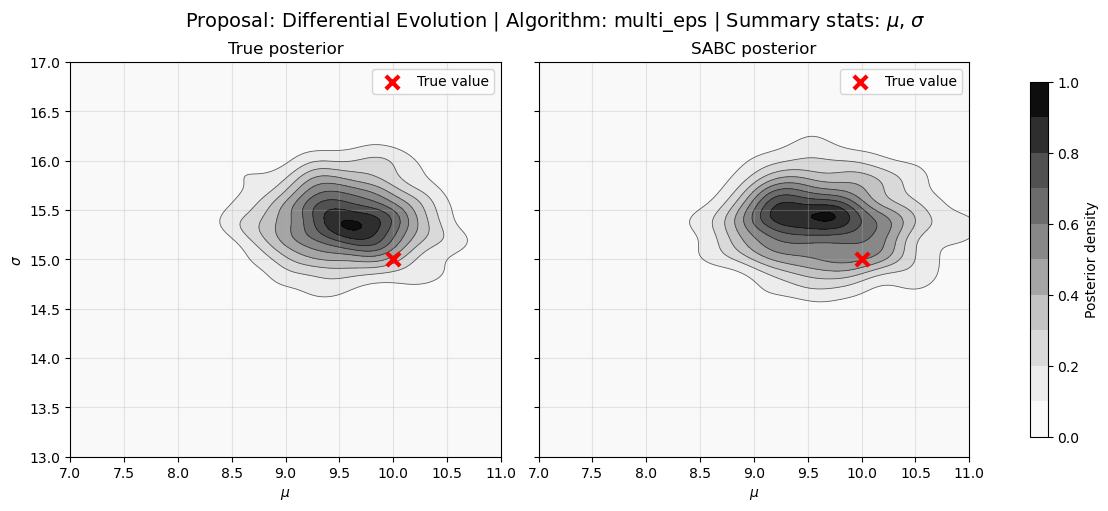

In [46]:

# -------------------------
# Compare true and sabc-inferred posteriors
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# -------------------------
# LEFT: True posterior
# -------------------------
ax = axes[0]
ax.grid(True, alpha=0.3, zorder=0)

cf = ax.contourf(
    MU,
    SIG,
    Z,
    levels=n_levels,
    cmap="Greys",
    zorder=1
)

ax.contour(
    MU,
    SIG,
    Z,
    levels=n_levels,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
    zorder=2
)

ax.scatter(
    true_mu,
    true_sigma,
    c="red",
    s=90,
    linewidths=3.0,
    marker="x",
    zorder=3,
    label="True value"
)

ax.set_xlim(mu_lims)
ax.set_ylim(sigma_lims)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\sigma$")
ax.set_title("True posterior")
ax.legend()

# -------------------------
# RIGHT: SABC posterior
# -------------------------
ax = axes[1]
ax.grid(True, alpha=0.3, zorder=0)

# KDE of SABC posterior (same style!)
values_sabc_mult = np.vstack([mu_mult, sigma_mult])
kde_sabc_mult = gaussian_kde(values_sabc_mult)

positions = np.vstack([MU.ravel(), SIG.ravel()])
Z_sabc_mult = kde_sabc_mult(positions).reshape(MU.shape)

ax.contourf(
    MU,
    SIG,
    Z_sabc_mult,
    levels=n_levels,
    cmap="Greys",
    zorder=1
)

ax.contour(
    MU,
    SIG,
    Z_sabc_mult,
    levels=n_levels,
    colors="black",
    linewidths=0.6,
    alpha=0.6,
    zorder=2
)

ax.scatter(
    true_mu,
    true_sigma,
    c="red",
    s=90,
    linewidths=3.0,
    marker="x",
    zorder=3,
    label="True value"
)

ax.set_xlabel(r"$\mu$")
ax.set_title(r"SABC posterior")
ax.legend()

# -------------------------
# ONE shared colorbar
# -------------------------
cbar = fig.colorbar(cf, ax=axes, shrink=0.9)
cbar.set_label("Posterior density")

fig.suptitle(
    r"Proposal: Differential Evolution | Algorithm: multi_eps | Summary stats: $\mu$, $\sigma$",
    fontsize=14
)

plt.show()

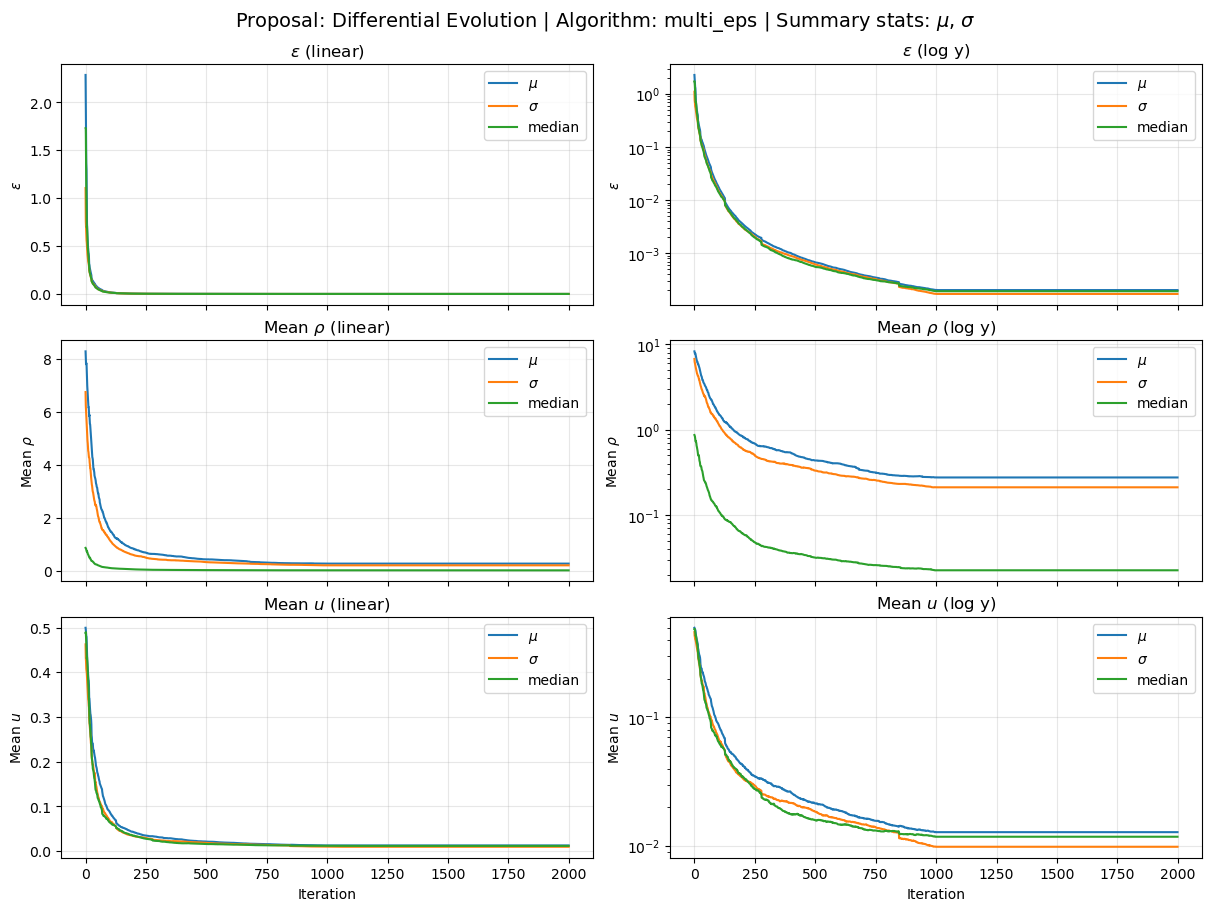

In [47]:

T = eps_dif_mult.shape[1]
it = np.arange(T)

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True
)

# =====================================================
# ε  (multi-eps: 3 components)
# =====================================================
# linear
ax = axes[0, 0]
ax.plot(it, eps_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, eps_dif_mult[1, :], label=r"$\sigma$")
ax.plot(it, eps_dif_mult[2, :], label=r"median")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"$\epsilon$")
ax.set_title(r"$\epsilon$ (linear)")
ax.legend()

# log
ax = axes[0, 1]
ax.plot(it, eps_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, eps_dif_mult[1, :], label=r"$\sigma$")  
ax.plot(it, eps_dif_mult[2, :], label=r"median")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"$\epsilon$")
ax.set_title(r"$\epsilon$ (log y)")
ax.legend()

# =====================================================
# ρ
# =====================================================
# linear
ax = axes[1, 0]
ax.plot(it, rho_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, rho_dif_mult[1, :], label=r"$\sigma$")
ax.plot(it, rho_dif_mult[2, :], label=r"median")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $\rho$")
ax.set_title(r"Mean $\rho$ (linear)")
ax.legend()

# log
ax = axes[1, 1]
ax.plot(it, rho_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, rho_dif_mult[1, :], label=r"$\sigma$")
ax.plot(it, rho_dif_mult[2, :], label=r"median")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $\rho$")
ax.set_title(r"Mean $\rho$ (log y)")
ax.legend()

# =====================================================
# u
# =====================================================
# linear
ax = axes[2, 0]
ax.plot(it, u_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, u_dif_mult[1, :], label=r"$\sigma$")
ax.plot(it, u_dif_mult[2, :], label=r"median")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $u$")
ax.set_xlabel("Iteration")
ax.set_title(r"Mean $u$ (linear)")
ax.legend()

# log
ax = axes[2, 1]
ax.plot(it, u_dif_mult[0, :], label=r"$\mu$")
ax.plot(it, u_dif_mult[1, :], label=r"$\sigma$")
ax.plot(it, u_dif_mult[2, :], label=r"median")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.set_ylabel(r"Mean $u$")
ax.set_xlabel("Iteration")
ax.set_title(r"Mean $u$ (log y)")
ax.legend()

fig.suptitle(
    r"Proposal: Differential Evolution | Algorithm: multi_eps | Summary stats: $\mu$, $\sigma$",
    fontsize=14
)

plt.show()

In [48]:
save_sabc_result(out_dif_mult_2, HERE / "test_results" / "out_DE_mult_3statsNoise.pkl")

# -------------------------
# out_dif_mult_2 = load_sabc_result(HERE / "test_results" / "out_DE_mult_3statsNoise.pkl")
# -------------------------